In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Use the famous boston dataset and find out if there is multicollinearity or not. If there is multicollinearity try to remove it with help of steps taught in the session.

In [2]:
# Link - https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv

df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

In [5]:
df.shape
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# Column meanings

# crim
# Per-capita crime rate in the area
# → Higher value = more crime

# zn
# Percentage of land zoned for large residential lots
# → Higher value = more spacious residential areas

# indus
# Percentage of non-retail business land
# → Higher value = more industrial/commercial land

# chas
# Charles River dummy variable

# 1 = area borders the Charles River

# 0 = does not

# nox
# Nitric oxide concentration (air pollution)
# → Higher value = worse air quality

# rm
# Average number of rooms per house
# → Higher value = larger houses

# age
# Percentage of houses built before 1940
# → Higher value = older housing

# dis
# Distance to major employment centers
# → Higher value = farther from jobs

# rad
# Accessibility to radial highways
# → Higher value = better highway access

# tax
# Property tax rate per $10,000
# → Higher value = higher taxes

# ptratio
# Student–teacher ratio in schools
# → Higher value = more students per teacher

# b
# Proportion related to racial demographics
# (historical variable; controversial and often excluded today)

# lstat
# Percentage of lower-status population
# → Higher value = lower socioeconomic status

# medv
# Median value of owner-occupied homes (in $1000s)
# → 24.0 means $24,000 (in 1970s dollars)

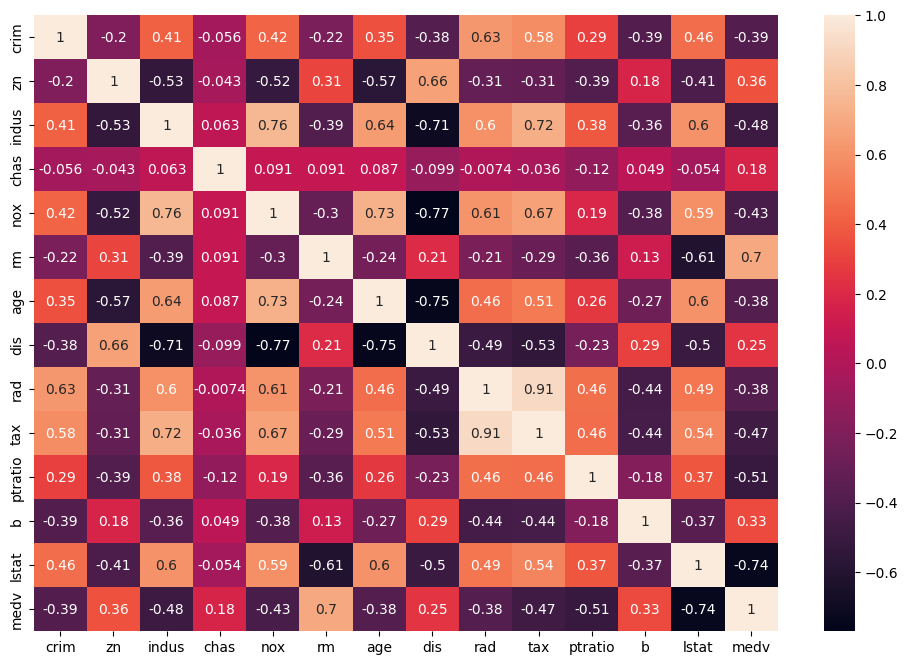

In [ ]:
plt.figure(figsize=(12, 8))  
sns.heatmap(df.corr(),annot = True)
plt.show()

#Consider the relation which is -0.8 < x < 0.8

In [ ]:
#dis istat,medv is looking like these column are having certain relation


In [21]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(df.shape[1]):
    vif.append(variance_inflation_factor(df, i))

In [20]:
df.shape[1]

14

In [ ]:
pd.DataFrame({'vif': vif}, index=df.columns).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
vif,2.131404,2.910004,14.485874,1.176266,74.004269,136.101743,21.398863,15.430455,15.36998,61.939713,87.227233,21.351015,12.615188,24.503206


In [ ]:
# Column = indus,nox,rm,age,dis,rad,tax,ptratio,b,istat,medv VIF score > 5 or 10 so it has multicolinearity

In [34]:
df_new = df.drop(columns = ["ptratio"])

In [35]:
vif = []

for i in range(df_new.shape[1]):
    vif.append(variance_inflation_factor(df_new, i))
    
pd.DataFrame({'vif': vif}, index=df_new.columns).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,b,lstat,medv
vif,2.131391,2.576275,14.282253,1.170135,73.997872,107.768453,21.379087,13.418224,15.343494,60.411677,19.439865,12.016137,23.885849


In [36]:
df_new = df_new.drop(columns = ["rm"])

vif = []

for i in range(df_new.shape[1]):
    vif.append(variance_inflation_factor(df_new, i))
    
pd.DataFrame({'vif': vif}, index=df_new.columns).T

,crim,zn,indus,chas,nox,age,dis,rad,tax,b,lstat,medv
vif,2.104099,2.55833,14.147928,1.162582,59.247225,20.427509,9.639018,15.130157,58.759509,19.222365,12.012673,13.431156


In [37]:
df_new = df_new.drop(columns = ["nox"])

vif = []

for i in range(df_new.shape[1]):
    vif.append(variance_inflation_factor(df_new, i))
    
pd.DataFrame({'vif': vif}, index=df_new.columns).T

,crim,zn,indus,chas,age,dis,rad,tax,b,lstat,medv
vif,2.103346,2.548017,13.152242,1.161474,17.056895,9.44615,15.049247,54.753156,18.593595,11.031436,11.446226


In [38]:
df_new = df_new.drop(columns = ["tax"])

vif = []

for i in range(df_new.shape[1]):
    vif.append(variance_inflation_factor(df_new, i))
    
pd.DataFrame({'vif': vif}, index=df_new.columns).T

,crim,zn,indus,chas,age,dis,rad,b,lstat,medv
vif,2.103261,2.465535,9.024818,1.142745,16.44947,8.722321,4.858231,18.131319,10.934458,11.385287


In [39]:
df_new = df_new.drop(columns = ["b"])

vif = []

for i in range(df_new.shape[1]):
    vif.append(variance_inflation_factor(df_new, i))
    
pd.DataFrame({'vif': vif}, index=df_new.columns).T

,crim,zn,indus,chas,age,dis,rad,lstat,medv
vif,2.095925,2.421949,8.855666,1.142321,15.731199,6.518545,4.733212,10.641862,8.500366


In [40]:
df_new = df_new.drop(columns = ["age"])

vif = []

for i in range(df_new.shape[1]):
    vif.append(variance_inflation_factor(df_new, i))
    
pd.DataFrame({'vif': vif}, index=df_new.columns).T

,crim,zn,indus,chas,dis,rad,lstat,medv
vif,2.09511,2.317242,8.044685,1.14169,6.395977,4.727054,7.012987,5.630097


In [55]:
# Second method

df_new = df.drop(columns = ["indus","ptratio","rm","nox","tax","b","age"])

vif = []

for i in range(df_new.shape[1]):
    vif.append(variance_inflation_factor(df_new, i))
    
pd.DataFrame({'vif': vif}, index=df_new.columns).T

,crim,zn,chas,dis,rad,lstat,medv
vif,2.087367,2.238439,1.137525,6.20703,4.06353,4.258222,4.82904
